# 08 · Hypothesis Testing

**Session 10 · Tue Oct 6 · 2 hours**

Hypothesis testing has a reputation for being confusing. It is not, once you see that it is a single
question asked carefully:

> **"If nothing were really going on, how often would I see data this striking?"**

If the answer is "almost never," you conclude something is going on. That is the whole method. The
vocabulary — null hypothesis, p-value, alpha, significance — is just precise naming for the parts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

In [2]:
ab = pd.read_csv(DATA / "ab_test.csv")
print(ab.groupby("variant")["satisfaction"].agg(["count", "mean", "std"]).round(3))

observed_diff = (ab.loc[ab.variant=="treatment", "satisfaction"].mean()
                 - ab.loc[ab.variant=="control",  "satisfaction"].mean())
print(f"\nobserved difference: {observed_diff:+.4f}")

           count   mean    std
variant                       
control      300  4.371  1.001
treatment    300  4.590  0.944

observed difference: +0.2187


The treatment group scored higher. **But is that real, or is it the kind of gap you would get from
random assignment alone?** You saw in notebook 03 that random variation produces apparent patterns
constantly. This is how you tell the difference.

## 1 · The permutation test — hypothesis testing with no formulas

Before any named test, here is the idea in its purest form.

If the treatment does nothing, then the labels "control" and "treatment" are meaningless stickers. We
could shuffle them randomly and get an equally valid dataset. So: **shuffle the labels thousands of
times and see how big a difference chance alone produces.**

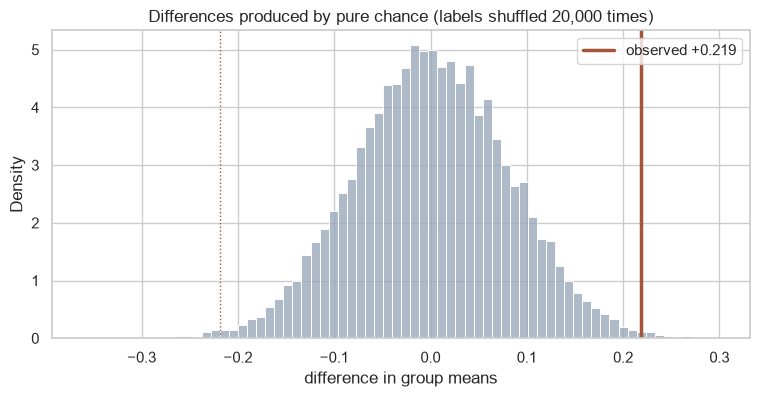

chance alone produced a gap this big or bigger in 0.70% of 20,000 shuffles

That proportion IS the p-value: p = 0.0070


In [3]:
values = ab.satisfaction.values
n_treat = (ab.variant == "treatment").sum()

null_diffs = np.empty(20_000)
for i in range(20_000):
    shuffled = rng.permutation(values)
    null_diffs[i] = shuffled[:n_treat].mean() - shuffled[n_treat:].mean()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(null_diffs, bins=70, ax=ax, color="#94a3b8", stat="density")
ax.axvline(observed_diff, color="#a5533b", lw=2.5, label=f"observed {observed_diff:+.3f}")
ax.axvline(-observed_diff, color="#a5533b", lw=1, ls=":")
ax.set_title("Differences produced by pure chance (labels shuffled 20,000 times)")
ax.set_xlabel("difference in group means"); ax.legend(); plt.show()

p_perm = np.mean(np.abs(null_diffs) >= abs(observed_diff))
print(f"chance alone produced a gap this big or bigger in {p_perm:.2%} of 20,000 shuffles")
print(f"\nThat proportion IS the p-value: p = {p_perm:.4f}")

**That is a p-value, and you just built one from scratch.** No distributions, no formulas, no tables.
It is a simulated frequency: *how often does chance alone do what I saw?*

Everything below is faster ways to compute this same number.

## 2 · The vocabulary, attached to what you just did

| Term | Symbol | What it was in your simulation |
|---|---|---|
| Null hypothesis | `H₀` | "the labels are meaningless" — the shuffling assumption |
| Alternative | `H₁` | "the treatment genuinely changes satisfaction" |
| Test statistic | — | the difference in means |
| Null distribution | — | the grey histogram |
| **p-value** | `p` | the share of the grey histogram beyond your red line |
| Significance level | `α` | the cutoff you picked *in advance*, usually 0.05 |

The `α` must be chosen **before** you look. Choosing it afterwards is how p-hacking starts.

## 3 · The t-test — the same answer, instantly

The t-test assumes the null distribution is a known shape (which the CLT from notebook 07
guarantees), so it can skip the simulation.

In [4]:
from scipy import stats

t = ab.loc[ab.variant=="treatment", "satisfaction"]
c = ab.loc[ab.variant=="control",  "satisfaction"]
res = stats.ttest_ind(t, c)

print(f"t-statistic: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.5f}")
print()
print(f"permutation test said: {p_perm:.5f}")
print(f"t-test said:           {res.pvalue:.5f}")
print("\nSame answer. The t-test is an efficient shortcut, not a different idea.")

t-statistic: 2.7526
p-value:     0.00609

permutation test said: 0.00700
t-test said:           0.00609

Same answer. The t-test is an efficient shortcut, not a different idea.


The **t-statistic** is just the difference measured in standard errors:
`t = (difference) / (standard error of the difference)`. A `t` of 2.75 means the gap is 2.75 standard
errors from zero — and from the 68/95/99.7 rule you already know that is unusual.

In [5]:
se_diff = np.sqrt(t.var(ddof=1)/len(t) + c.var(ddof=1)/len(c))
print(f"difference:            {observed_diff:+.4f}")
print(f"SE of the difference:   {se_diff:.4f}")
print(f"t = difference / SE  =  {observed_diff/se_diff:.4f}")
print(f"scipy's t           =  {res.statistic:.4f}")

difference:            +0.2187
SE of the difference:   0.0794
t = difference / SE  =  2.7526
scipy's t           =  2.7526


## 4 · What a p-value is NOT

This gets examined, and it gets argued in ethics papers. `p = 0.006` does **not** mean:

- ❌ "There is a 0.6% chance the null hypothesis is true." A p-value assumes `H₀` and cannot
  simultaneously assign it a probability.
- ❌ "There is a 99.4% chance the treatment works."
- ❌ "The effect is large or important."

It means, precisely: **if the treatment did nothing, data this extreme would arise 0.6% of the time.**

### The size problem

With enough data, *any* non-zero difference becomes statistically significant — including one far too
small to care about.

In [6]:
# A trivially small true effect: 0.02 points on a 5-point scale.
for n in (100, 1_000, 10_000, 100_000):
    a = rng.normal(4.50, 1.0, n)
    b = rng.normal(4.52, 1.0, n)
    p = stats.ttest_ind(b, a).pvalue
    flag = "SIGNIFICANT" if p < .05 else ""
    print(f"n={n:>7,}  diff≈0.02  p={p:.4f}  {flag}")

print("\nThe effect is identical every time. Only n changed. At n=100,000 a difference")
print("nobody could perceive is 'highly significant'. Hence: ALWAYS report the effect")
print("size alongside the p-value. 'Significant' means detectable, not important.")

n=    100  diff≈0.02  p=0.0266  SIGNIFICANT
n=  1,000  diff≈0.02  p=0.0265  SIGNIFICANT


n= 10,000  diff≈0.02  p=0.1181  
n=100,000  diff≈0.02  p=0.0000  SIGNIFICANT

The effect is identical every time. Only n changed. At n=100,000 a difference
nobody could perceive is 'highly significant'. Hence: ALWAYS report the effect
size alongside the p-value. 'Significant' means detectable, not important.


## 5 · Two ways to be wrong

| | `H₀` is actually true | `H₀` is actually false |
|---|---|---|
| **You reject `H₀`** | **Type I error** (false positive), rate `α` | correct ✓ |
| **You keep `H₀`** | correct ✓ | **Type II error** (false negative), rate `β` |

**Power** is `1 − β`: the chance of detecting a real effect that is there. Underpowered studies are
the quiet epidemic of applied research — they fail to find real effects and get reported as "no
effect found," which is a different claim entirely.

In [7]:
true_effect, sd = 0.22, 1.0
print("power to detect a real 0.22-point effect:\n")
for n in (30, 100, 300, 1000):
    hits = sum(stats.ttest_ind(rng.normal(4.5+true_effect, sd, n),
                               rng.normal(4.5, sd, n)).pvalue < .05
               for _ in range(1500))
    print(f"n={n:>5} per group   power = {hits/1500:>6.1%}"
          f"   {'(under-powered)' if hits/1500 < .8 else '(adequate)'}")
print("\n80% power is the usual minimum. At n=30 you would MISS this real effect")
print("four times out of five -- and might then report that it does not exist.")

power to detect a real 0.22-point effect:

n=   30 per group   power =  12.3%   (under-powered)
n=  100 per group   power =  34.9%   (under-powered)
n=  300 per group   power =  76.1%   (under-powered)


n= 1000 per group   power = 100.0%   (adequate)

80% power is the usual minimum. At n=30 you would MISS this real effect
four times out of five -- and might then report that it does not exist.


## Your turn

**Exercise 1.** In the `lending` data, is mean `credit_score` different between `applicant_group` A
and B? Run a t-test, report the p-value *and* the effect size in points, and write one sentence you
would be willing to put in a paper.

In [8]:
# your code here

In [ ]:
lending = pd.read_csv(DATA / "lending.csv")
a = lending.loc[lending.applicant_group=="A", "credit_score"]
b = lending.loc[lending.applicant_group=="B", "credit_score"]
res = stats.ttest_ind(a, b)

print(f"group A mean: {a.mean():.1f}   group B mean: {b.mean():.1f}")
print(f"difference:   {a.mean()-b.mean():.1f} points")
print(f"t = {res.statistic:.2f},  p = {res.pvalue:.2e}")
print(f"Cohen's d = {(a.mean()-b.mean())/np.sqrt((a.var()+b.var())/2):.3f}")

# "Group A applicants have a mean credit score 48.9 points higher than group B
#  (t = 21.4, p < 0.001, d = 0.75), a large and highly significant difference."
#
# Note carefully what this does NOT establish: WHY. The statistic is silent on whether
# this reflects creditworthiness or an unequal historical data-generating process --
# and that question, not the p-value, is what PhDAI 832 is about.

**Exercise 2.** Demonstrate the multiple-comparisons problem: run 200 t-tests between two groups
drawn from the *same* distribution (so `H₀` is true every time). How many come out "significant"?

In [10]:
# your code here

In [ ]:
false_positives = sum(stats.ttest_ind(rng.normal(0,1,80), rng.normal(0,1,80)).pvalue < .05
                      for _ in range(200))
print(f"significant results from 200 tests where H₀ is TRUE: {false_positives}")
print(f"that is {false_positives/200:.1%} -- which is exactly α = 5%, as designed")
print()
print("P(at least one false positive in 20 tests) =",
      f"{1 - 0.95**20:.1%}")

# This is p-hacking's engine. Test 20 things and you will probably find "something
# significant" even when nothing is real. It is why pre-registration exists, and why
# corrections (Bonferroni: use α/m) exist. In an AI audit context it matters enormously:
# test a model across 20 demographic subgroups and you WILL find a disparity by chance.

## What you did today

- Built a **p-value from scratch** by shuffling labels — no formula needed.
- Saw the t-test reproduce that number instantly, and understood `t` as "differences per standard error."
- Learned what a p-value is **not**, and that significance ≠ importance.
- Type I vs Type II error and **power** — and that underpowered studies produce false reassurance.
- The multiple-comparisons trap, which matters directly for fairness auditing.

**Next:** `09_bootstrap.ipynb` — confidence intervals for anything, in ten lines.